# The Compute Business: Capacity, Utilization, and Profit
**Lesson 1 · 10–15 minutes · basic Python**

You rent a small GPU fleet and sell its compute to one customer. You pay for every
rented hour, but earn revenue only on consumed, billed hours. Will the contract
cover its rental bill?

By the end, you can translate capacity into GPU-hours, calculate revenue and
contribution profit, find break-even utilization, and explain why a positive
selling/rental price spread can still produce a loss.

Paying for unused capacity has real precedents: [AWS Capacity Reservations](https://docs.aws.amazon.com/AWSEC2/latest/UserGuide/capacity-reservations-pricing-billing.html)
charge for unused reserved instances. Our GPU agreement is hypothetical; this is
not a claim about every provider's terms.

**Setup:** follow the repository README, then run cells in order. We assume identical,
fully available GPUs and bill all consumed hours. Initially exclude resale, demand
beyond capacity, ancillary expenses, taxes, financing, and derivatives.

In [1]:
# Install the teaching package from GitHub when running in Google Colab.
# Local Jupyter uses the repository's existing environment.
import subprocess
import sys

if "google.colab" in sys.modules:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "liquid-compute[colab] @ git+https://github.com/zach189/education.git@main",
        ]
    )
    from google.colab import output

    output.enable_custom_widget_manager()

In [2]:
from liquid_compute import compute_monthly_economics
from liquid_compute.education import (
    explore_monthly_economics,
    plot_profit_by_utilization,
    show_monthly_results,
)

# HYPOTHETICAL teaching inputs — not market quotes. Edit these and rerun below.
gpu_count = 10  # GPUs rented
hours_per_month = 30 * 24  # hours per GPU; illustrative 30-day month
rental_usd_per_gpu_hour = 2.0  # USD / purchased GPU-hour
customer_usd_per_gpu_hour = 4.0  # USD / consumed and billed GPU-hour
utilization_fraction = 0.75  # billed GPU-hours / purchased GPU-hours

## From GPUs to GPU-hours
A GPU is capacity; a **GPU-hour** is one GPU available for one hour. Ten GPUs
rented for 720 hours buy `10 × 720 = 7,200 GPU-hours`. At 75% utilization,
`7,200 × 0.75 = 5,400 GPU-hours` are billed; 1,800 remain unused.

Here, utilization measures **billed hours**, not processor activity. Both rates
are dollars per GPU-hour, but the rental rate applies to *all purchased hours*
and the customer rate only to *billed hours*. Read each multiplication below
before running it. What revenue and rental expense do you expect?

In [3]:
purchased_gpu_hours = gpu_count * hours_per_month
billed_gpu_hours = purchased_gpu_hours * utilization_fraction
unused_gpu_hours = purchased_gpu_hours - billed_gpu_hours
revenue_usd = billed_gpu_hours * customer_usd_per_gpu_hour
rental_expense_usd = purchased_gpu_hours * rental_usd_per_gpu_hour
contribution_profit_usd = revenue_usd - rental_expense_usd
contribution_margin_fraction = (
    contribution_profit_usd / revenue_usd if revenue_usd > 0 else None
)
break_even_fraction = rental_usd_per_gpu_hour / customer_usd_per_gpu_hour

print(f"Revenue: ${revenue_usd:,.2f}")
print(f"Rental expense: ${rental_expense_usd:,.2f}")
print(f"Contribution profit: ${contribution_profit_usd:,.2f}")

Revenue: $21,600.00
Rental expense: $14,400.00
Contribution profit: $7,200.00


## Dollars are not percentages
Our **contribution profit** is revenue minus the entire rental bill: a simplified
contribution margin before excluded costs. It is not net income. Unlike the
[textbook contribution margin](https://openstax.org/books/principles-managerial-accounting/pages/3-1-explain-contribution-margin-and-calculate-contribution-margin-per-unit-contribution-margin-ratio-and-total-contribution-margin)
(revenue minus variable costs), our defined measure subtracts a rental commitment
that stays fixed when utilization changes.

The default $7,200 profit is `7,200 / 21,600 = 33.33%` of revenue. It is **not** a
50% margin just because the selling price is twice the rental rate. With no
revenue, this percentage is undefined; display N/A.

Now use the packaged function: the same arithmetic, with documented assumptions
and runtime checks. Inputs must be finite, capacity/hours/prices positive, and
utilization between 0 and 1. A type hint alone cannot check any of these conditions.

In [4]:
assumptions = dict(
    gpu_count=gpu_count,
    hours_per_month=hours_per_month,
    rental_usd_per_gpu_hour=rental_usd_per_gpu_hour,
    customer_usd_per_gpu_hour=customer_usd_per_gpu_hour,
    utilization_fraction=utilization_fraction,
)
result = compute_monthly_economics(**assumptions)
show_monthly_results(result)

| Result | Value | Unit |
|---|---:|---|
| Purchased | 7,200.00 | GPU-hours |
| Billed | 5,400.00 | GPU-hours |
| Unused | 1,800.00 | GPU-hours |
| Revenue | 21,600.00 | USD / modeled month |
| Rental expense | 14,400.00 | USD / modeled month |
| Contribution profit | 7,200.00 | USD / modeled month |
| Margin | 33.33% | % of revenue |
| Break-even utilization | 50.00% | billed / purchased hours |

## How busy must the fleet be?
[Break-even](https://openstax.org/books/principles-managerial-accounting/pages/3-2-calculate-a-break-even-point-in-units-and-dollars)
is where revenue equals the costs included in the model. If $N$ is GPU count,
$H$ monthly hours, $u$ utilization, $p$ customer price, and $c$ rental price:

$$\Pi = NH(up-c),\qquad NHup=NHc\implies u_{\mathrm{BE}}=\frac{c}{p}.$$

At our prices, `2 / 4 = 50%`. Below that, billed hours cannot cover the full
rental commitment. Positive capacity scales dollar gains and losses but cancels
from the threshold. A threshold above 100% is mathematically valid and physically
unattainable within this fleet. The chart keeps the feasible range at 0–100%.

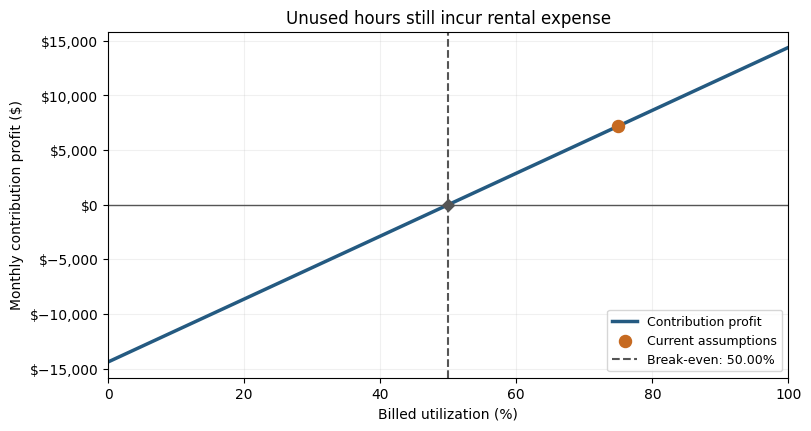

In [5]:
plot_profit_by_utilization(**assumptions);

## Try the controls
Predict what changing one input will do, then try it. This explorer keeps its
controls, chart, and results together. It is independent of the static chart above,
the assumptions cell, and the fixed experiments below. The initial utilization
preserves your entered value; dragging the slider moves in percentage-point steps.

If controls appear only as text or do not respond, **edit the assumptions cell and
rerun the following cells**. The arithmetic, table, and static chart do not require
widgets. See [Jupyter's widget setup guidance](https://ipywidgets.readthedocs.io/en/stable/user_install.html).

The experiments below include saved worked results, so you can read the lesson
like a book. If you want to test your intuition, predict each result before
reading on, or change the inputs and rerun the example.

In [6]:
explore_monthly_economics(**assumptions);

## Experiment 1 — a positive spread, but a loss?
**Optional prediction:** keep the default prices but bill only 25% of purchased
hours. Is the $2 positive price spread enough? Which changes: revenue, expense,
or both? Each experiment below uses fixed inputs, independent of the controls.

In [7]:
low_usage = compute_monthly_economics(
    gpu_count=10,
    hours_per_month=720,
    rental_usd_per_gpu_hour=2,
    customer_usd_per_gpu_hour=4,
    utilization_fraction=0.25,
)
show_monthly_results(low_usage)

| Result | Value | Unit |
|---|---:|---|
| Purchased | 7,200.00 | GPU-hours |
| Billed | 1,800.00 | GPU-hours |
| Unused | 5,400.00 | GPU-hours |
| Revenue | 7,200.00 | USD / modeled month |
| Rental expense | 14,400.00 | USD / modeled month |
| Contribution profit | -7,200.00 | USD / modeled month |
| Margin | -100.00% | % of revenue |
| Break-even utilization | 50.00% | billed / purchased hours |

**What this shows:** With these inputs, 25% utilization means billing only 1,800 of the 7,200 purchased GPU-hours. Revenue is \$7,200, but the rental bill remains \$14,400, leaving a **\$7,200 loss**.

The customer pays more per hour than you pay to rent it, but too few hours earn revenue. **A positive price spread is not enough: billed utilization must reach the 50% break-even threshold to cover the entire rental commitment.**

## Experiment 2 — does a larger fleet fix the economics?
**Optional prediction:** double GPUs from 10 to 20 while utilization stays at 75%. What happens
to dollar profit, percentage margin, and break-even? Holding utilization constant
means the customer also consumes twice as many hours; extra demand is an assumption,
not an automatic consequence of renting more GPUs.

In [8]:
for count in (10, 20):
    scaled = compute_monthly_economics(
        gpu_count=count,
        hours_per_month=720,
        rental_usd_per_gpu_hour=2,
        customer_usd_per_gpu_hour=4,
        utilization_fraction=0.75,
    )
    print(f"{count} GPUs")
    show_monthly_results(scaled)

10 GPUs


| Result | Value | Unit |
|---|---:|---|
| Purchased | 7,200.00 | GPU-hours |
| Billed | 5,400.00 | GPU-hours |
| Unused | 1,800.00 | GPU-hours |
| Revenue | 21,600.00 | USD / modeled month |
| Rental expense | 14,400.00 | USD / modeled month |
| Contribution profit | 7,200.00 | USD / modeled month |
| Margin | 33.33% | % of revenue |
| Break-even utilization | 50.00% | billed / purchased hours |

20 GPUs


| Result | Value | Unit |
|---|---:|---|
| Purchased | 14,400.00 | GPU-hours |
| Billed | 10,800.00 | GPU-hours |
| Unused | 3,600.00 | GPU-hours |
| Revenue | 43,200.00 | USD / modeled month |
| Rental expense | 28,800.00 | USD / modeled month |
| Contribution profit | 14,400.00 | USD / modeled month |
| Margin | 33.33% | % of revenue |
| Break-even utilization | 50.00% | billed / purchased hours |

**What this shows:** At 75% utilization, doubling the fleet doubles both billed hours and rental expense. Contribution profit rises from \$7,200 to \$14,400, while the percentage margin stays at **33.33%** and break-even utilization stays at **50%**.

**Scale changes the dollar amounts, not the underlying economics per purchased hour.** This result assumes the customer consumes twice as many hours. Renting more GPUs does not itself create that demand; below break-even utilization, doubling capacity at the same utilization would double the loss.

## Experiment 3 — can being fully booked rescue this contract?

**Optional prediction:** rental rises to \$5/GPU-hour while the customer still pays \$4/GPU-hour.

What break-even utilization would be required? Could higher utilization alone solve the problem?

Try these prices in the controls to see the infeasible threshold annotation.

In [9]:
unfavorable = compute_monthly_economics(
    gpu_count=10,
    hours_per_month=720,
    rental_usd_per_gpu_hour=5,
    customer_usd_per_gpu_hour=4,
    utilization_fraction=1,
)
show_monthly_results(unfavorable)

| Result | Value | Unit |
|---|---:|---|
| Purchased | 7,200.00 | GPU-hours |
| Billed | 7,200.00 | GPU-hours |
| Unused | 0.00 | GPU-hours |
| Revenue | 28,800.00 | USD / modeled month |
| Rental expense | 36,000.00 | USD / modeled month |
| Contribution profit | -7,200.00 | USD / modeled month |
| Margin | -25.00% | % of revenue |
| Break-even utilization | 125.00% | billed / purchased hours |

**What this shows:** Even at full utilization, revenue is only \$28,800 against \$36,000 of rent: a **\$7,200 loss**. Every purchased GPU-hour is billed, but each earns \$4 while costing \$5.

The break-even ratio is `5 / 4 = 125%`. That would require billing 9,000 GPU-hours from just 7,200 purchased hours, which this model does not allow. **Higher utilization cannot rescue these prices.** The operator needs a higher customer price, a lower rental rate, or different contract terms.

## Takeaway and limitations
You buy capacity but sell consumed hours. The rental/customer price ratio tells
you the minimum billed utilization needed to cover rent; a positive price spread
alone cannot do that. Dollar profit and percentage margin answer different questions.

This deterministic model calculates contractual amounts given usage. It does not
forecast demand, value a derivative, or schedule cash payments. Excluded costs
would reduce the money left over. We assumed every consumed hour is collectible
and every rented GPU available; real agreements may differ.

### References
- [AWS: Capacity Reservation pricing and billing](https://docs.aws.amazon.com/AWSEC2/latest/UserGuide/capacity-reservations-pricing-billing.html)
- [OpenStax: Break-even analysis](https://openstax.org/books/principles-managerial-accounting/pages/3-2-calculate-a-break-even-point-in-units-and-dollars)
- [OpenStax: Contribution margin](https://openstax.org/books/principles-managerial-accounting/pages/3-1-explain-contribution-margin-and-calculate-contribution-margin-per-unit-contribution-margin-ratio-and-total-contribution-margin)
- [Jupyter Widgets: Installation](https://ipywidgets.readthedocs.io/en/stable/user_install.html)

**Next lesson:** This contract can look profitable overall while requiring cash
before the customer pays. How much cash must the operator fund, and for how long?